# Tiempo de retardo del lazo: escalón y rampa

**E-517 + E-545 · eje A · datos del 2026-09-01 y 2026-09-07**

Este notebook hace **una sola cosa**: mide **el tiempo de retardo del lazo cerrado**,
$\tau_{\rm lag}$ — el único parámetro dinámico que entra en el diseño de un scan — y lo
mide **dos veces con dos entradas distintas** para ver si dan lo mismo.

- **Parte 1 · escalón** (§1–4): de dónde sale $\tau$, y por qué el estimador que veníamos
  usando estaba sesgado.
- **Parte 2 · rampa** (§5–7): cómo tiene que ser la medición, cuáles de las corridas que ya
  hay la cumplen, y el $\tau$ que sale de la zona de velocidad constante.

No hay asentamiento acá, ni DCO como tema propio.

---

### La definición (y por qué no es la que veníamos usando)

Veníamos leyendo el escalón como si el lazo fuera de **primer orden**: medir $t_{10-90}$
y dividir por 2.197. Eso da $\approx 8.9$ ms, y **no coincide** con los 12.1 ms que da la
rampa. La discrepancia no es ruido: es que el lazo **no es de primer orden**, y
$t_{10-90}/2.197$ solo tiene sentido si lo fuera.

La cantidad correcta — la que sí es igual en escalón y en rampa, para **cualquier**
sistema lineal estable — es el **primer momento** de la respuesta:

$$\boxed{\;\tau_{\rm lag} \;\equiv\; \int_0^{\infty}\big[1-y(t)\big]\,dt\;}$$

con $y(t)$ la respuesta al escalón normalizada ($y=0$ antes, $y\to1$ después).
Es literalmente **el área que le falta a la respuesta para ser instantánea**.
No hay modelo, no hay ajuste, no hay que suponer el orden del sistema.

### Por qué eso es lo mismo que el retraso en rampa

Con lazo cerrado $T(s)$ y sensibilidad $S(s)=1-T(s)$:

$$\int_0^{\infty}\!\big[1-y(t)\big]dt \;=\; \left.\frac{1-T(s)}{s}\right|_{s\to0} \;=\; \left.\frac{S(s)}{s}\right|_{s\to0}$$

Y frente a una rampa $x_{\rm ref}=vt$ el error estacionario es $e_{ss}=v\,\lim_{s\to0}S(s)/s$. O sea:

$$e_{ss} = v\cdot\tau_{\rm lag}$$

**El mismo número.** Medirlo en el escalón *predice* el retraso en rampa. Eso convierte
el par escalón/rampa en un test falsable, no en dos mediciones que "más o menos dan parecido".

### Dónde entra el PI

El lazo del E-802.55 es un **PI analógico**, $C(s)=K_P+K_I/s$. El integrador pone un polo
en el origen ⇒ el lazo es de **tipo 1**:

| entrada | error en régimen |
|---|---|
| escalón | **0** (por eso el escalón termina clavado en el target) |
| rampa $vt$ | $v/K_v$, **constante** |
| parábola | $\infty$ |

con la constante de error de velocidad $K_v=\lim_{s\to0}sC(s)P(s)=K_I\,P(0)$. Entonces:

$$\tau_{\rm lag}=\frac{1}{K_v}=\frac{1}{K_I\,P(0)}$$

Esto responde la pregunta de "cómo es el retardo en el caso del PI": **el retardo del lazo
es el recíproco de la ganancia integral en lazo abierto.** No es un tiempo de transporte,
no es un retardo de propagación: es lo que tarda el integrador en acumular la corrección.
Y se mide sin abrir la caja, con el área de arriba.

*(Aparte: sí existe además un retardo de transporte real, de $\sim$1 ms, que se ve como
el tiempo en que la platina no se mueve nada después del salto. Lo medimos abajo, pero
es chico y no es lo que domina.)*

In [17]:
# ── Setup ────────────────────────────────────────────────────────────────────
# En Colab: clona el repo público (los CSV están versionados, ~32 MB).
# En local: si ya estás parado en el repo, no clona nada.
from pathlib import Path
import sys, os

if Path("datos/raw").exists():
    REPO = Path(".")
elif Path("laboratorio-7/datos/raw").exists():
    REPO = Path("laboratorio-7")
else:
    os.system("git clone -q --depth 1 https://github.com/franaguirreram/laboratorio-7.git")
    REPO = Path("laboratorio-7")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
trapz = getattr(np, "trapezoid", None) or np.trapz     # numpy <2 / >=2

RAW, META = REPO/"datos"/"raw", REPO/"datos"/"metadata"
T_SERVO = 40e-6          # s — ciclo de servo, MEDIDO (qSPA 0x0E000200 = 40.0000 us)
TAU_RAMPA_MS = 12.1      # ms — valor a contrastar, de las 43 corridas de rampa
PISO_SIGNIF = 0.23       # ±23 % — repetibilidad punto a punto; el piso de significancia

plt.rcParams.update({'font.family':'serif','font.size':9,'figure.dpi':120,
                     'axes.grid':True,'grid.alpha':.25,'grid.linewidth':.5})
print(f"repo: {REPO.resolve()}   escalones: {len(list(RAW.glob('E517_escalon_*.csv')))}")

repo: /Users/fran/Desktop/LABORATORIO 7/notebooks/laboratorio-7   escalones: 59


---
## 1. Cargar el escalón, respetando cómo lo genera el hardware

Tres cosas del generador de ondas que **cambian cómo hay que leer el CSV**, y que si se
ignoran contaminan el resultado:

1. **El generador no interpola: avanza un punto de la tabla cada `WTR` ciclos de servo
   y se queda quieto en el medio.** Lo que la platina recibe es una *escalera* de
   micro-escalones $\Delta x$ cada $\rm WTR\times40\,\mu s$. En la corrida de escalón la
   escalera tiene un solo peldaño (50 puntos abajo, 8142 arriba), así que el comando es un
   escalón genuino — pero **el instante del salto solo se conoce a menos de un tick**
   $\rm WTR\times40\,\mu s$. Con `WTR=25` eso es 1 ms, un 8 % de $\tau$: **para medir
   retardo hay que usar WTR chico.**

2. **El grabador tiene su propio reloj, `RTR`**: una muestra cada $\rm RTR\times40\,\mu s$,
   8192 muestras. La columna `t_ms` del CSV está escrita por el script del host y en
   corridas viejas está **mal escalada** (`T_SERVO_US` nunca se le mandaba al controlador).
   Acá el eje temporal se **reconstruye desde `RTR`** y se ignora `t_ms`.

3. **El grabador sigue grabando después de que la trayectoria terminó**, y ahí el canal de
   posición comandada **pasa a valer 0**. Si eso pasa, el salto más grande del target está
   al *final* y vale $-100\ \mu$m. Se detecta y se descarta la corrida.

**Qué es `S` en el código.** `S = tgt[i] - tgt[i-1]` es **el tamaño del escalón
comandado, con signo**, en nm. Se usa para dos cosas y se guarda para una tercera:

- **normalizar**: `y = (cur-base)/S` va de 0 a 1 y `e = (tgt[i]-cur)/S` va de 1 a 0,
  *sea el escalón de +20 nm o de −100 µm*. El signo se cancela solo (numerador y
  denominador cambian de signo juntos), así que un escalón hacia abajo se analiza igual
  que uno hacia arriba, sin ningún `if`. Es lo que permite poner un escalón de 200 nm y
  uno de 100 µm en los mismos ejes y comparar τ;
- **volver a unidades físicas** cuando hace falta: `y*|S|` en nm, para comparar la subida
  contra el ruido en el panel del tiempo muerto;
- **filtrar**: se guarda como `S_nm` porque el criterio de validez es por tamaño de
  escalón (≥200 nm) — y `if abs(S) < 5: return None` descarta archivos donde no hay
  ningún escalón real.

El cuanto del target es 0.1 nm (21 bits sobre 200 µm). El ruido medido en la ventana
pre-escalón es 0.4 nm rms (mediana de las 59 corridas) y sube a ~1.7 nm en ventanas largas,
donde entran los 50 Hz y la deriva. En los dos casos el cuanto queda por debajo: **la
cuantización del comando no limita nada acá.**

In [18]:
# ── Carga ────────────────────────────────────────────────────────────────────
def leer_metadata(p):
    d = {}
    for ln in open(p, encoding="utf-8", errors="replace"):
        ln = ln.strip()
        if "=" in ln and not ln.startswith("#"):
            k, v = ln.split("=", 1); d[k.strip()] = v.strip()
    return d

def cargar_escalon(csv):
    """Devuelve la corrida normalizada, o None si no sirve para medir retardo."""
    nom = csv.stem
    fmeta = META / f"{nom}_metadata.txt"
    if not fmeta.exists():
        return None
    d = leer_metadata(fmeta)
    wtr, rtr = int(d["wtr"]), int(d["rtr"])

    df  = pd.read_csv(csv)
    tgt = df.target_um.values * 1e3          # nm
    cur = df.current_um.values * 1e3         # nm
    n   = len(tgt)

    dt = rtr * T_SERVO * 1e3                 # ms/muestra  ← reconstruido, NO de t_ms

    # (3) trampa de la cola del recorder: comandada -> 0 al terminar la trayectoria
    salto_global = np.abs(np.diff(tgt))
    i = int(np.argmax(salto_global[: n // 2])) + 1        # el escalón vive en la 1ª mitad
    if salto_global.max() > 3 * salto_global[: n // 2].max():
        return None                                       # hay un salto espurio después
    S = tgt[i] - tgt[i - 1]                                # nm, con signo
    if abs(S) < 5:
        return None

    npre  = min(i, 50)
    base  = cur[i - npre : i].mean()
    sigma = cur[i - npre : i].std()                        # ruido pre-escalón, nm rms

    t = (np.arange(n) - i) * dt                            # t=0 = 1ª muestra post-salto
    y = (cur - base) / S                                   # respuesta normalizada
    g = (tgt - tgt[i - 1]) / S                             # target normalizado (la escalera)
    e = (tgt[i] - cur) / S                                 # error normalizado (1 -> 0)

    return dict(nombre=nom, t=t, y=y, g=g, e=e, S_nm=S, dt_ms=dt, wtr=wtr, rtr=rtr,
                dco=(d["dco"] == "True"), sigma_nm=sigma,
                amp_um=float(d["amplitud_um"]), ventana_ms=t[-1],
                tick_ms=wtr * T_SERVO * 1e3, etiqueta=d.get("etiqueta", ""))

CORRIDAS = [c for c in (cargar_escalon(f) for f in sorted(RAW.glob("E517_escalon_*.csv")))
            if c is not None]
print(f"{len(CORRIDAS)} corridas de escalón cargadas")
print(f"saltos:   {sorted({abs(round(c['S_nm'])) for c in CORRIDAS})} nm")
print(f"ruido pre-escalón (mediana): {np.median([c['sigma_nm'] for c in CORRIDAS]):.2f} nm rms")

59 corridas de escalón cargadas
saltos:   [20, 200, 2000, 20000, 100000] nm
ruido pre-escalón (mediana): 0.40 nm rms


---
## 2. Mirar una corrida antes de medir nada

`RTR = 1` → una muestra cada 40 µs, ventana 328 ms. Es la corrida con mejor resolución
temporal, y por eso la que sirve para ver la forma real del arranque.

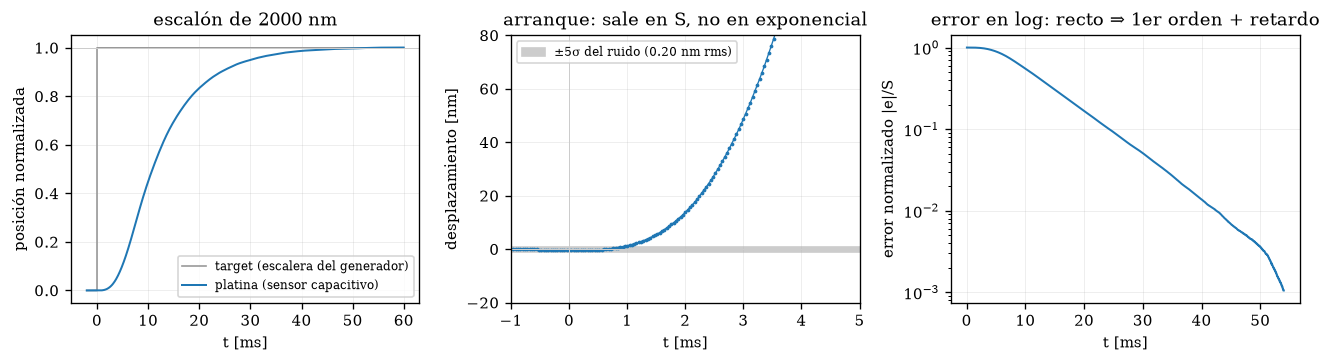

E517_escalon_rtrdco_rtr1_dco0_20260907_164645_r0   dt = 40 µs   tick del generador = 40 µs


In [19]:
# ── Figura 1: la respuesta, y el arranque en detalle ─────────────────────────
r = next(c for c in CORRIDAS if c["rtr"] == 1 and not c["dco"] and abs(c["S_nm"]) > 1000)

fig, ax = plt.subplots(1, 3, figsize=(11, 3.1))

m = (r["t"] > -5) & (r["t"] < 60)
ax[0].step(r["t"][m], r["g"][m], where="post",
           color="0.6", lw=1, label="target (escalera del generador)")
ax[0].plot(r["t"][m], r["y"][m], "C0", lw=1.2, label="platina (sensor capacitivo)")
ax[0].axhline(1, color="0.8", lw=.6)
ax[0].set(xlabel="t [ms]", ylabel="posición normalizada", title=f"escalón de {abs(r['S_nm']):.0f} nm")
ax[0].legend(loc="lower right", fontsize=7)

m = (r["t"] > -1) & (r["t"] < 5)
ax[1].plot(r["t"][m], r["y"][m] * abs(r["S_nm"]), "C0.-", ms=2.5, lw=.8)
ax[1].axhline(0, color="0.8", lw=.6); ax[1].axvline(0, color="0.8", lw=.6)
ax[1].fill_between([-1, 5], -5*r["sigma_nm"], 5*r["sigma_nm"], color="0.8", zorder=0,
                   label=f"±5σ del ruido ({r['sigma_nm']:.2f} nm rms)")
ax[1].set(xlabel="t [ms]", ylabel="desplazamiento [nm]", xlim=(-1, 5),
          ylim=(-0.01*abs(r["S_nm"]), 0.04*abs(r["S_nm"])),
          title="arranque: sale en S, no en exponencial")
ax[1].legend(loc="upper left", fontsize=7)

m = (r["t"] > 0) & (r["t"] < 60) & (r["e"] > 1e-3)
ax[2].semilogy(r["t"][m], r["e"][m], "C0", lw=1.2)
ax[2].set(xlabel="t [ms]", ylabel="error normalizado |e|/S",
          title="error en log: recto ⇒ 1er orden + retardo")

fig.tight_layout(); plt.show()
print(f"{r['nombre']}   dt = {r['dt_ms']*1e3:.0f} µs   tick del generador = {r['tick_ms']*1e3:.0f} µs")

**Qué se ve, y qué descarta cada panel:**

- **Centro.** La platina **no arranca con pendiente máxima**: se queda quieta ~1 ms y después
  acelera. Un primer orden puro arranca con su pendiente más grande en $t=0$. Esto solo ya
  invalida $t_{10-90}/2.197$ — y explica por qué ese número daba 8.9 ms en vez de 12.
- **Derecha.** En escala log el error es **una recta** en casi todo el rango. Eso sí es
  primer orden... pero *desplazado en el tiempo*. La firma de **primer orden + retardo**:
  $\;e(t)/S = e^{-(t-L)/\tau}$.
- **Izquierda.** Después de llegar hay cola. Con `DCO=False` es chica; con `DCO=True` hay una
  excursión lenta de decenas de nm que **sesga el área hacia abajo**. Por eso el τ se mide
  con **DCO apagado**.

---
## 3. Cuatro estimadores del mismo número

Se calculan los cuatro sobre cada corrida, a propósito: **si el sistema fuera de primer
orden puro los cuatro darían lo mismo.** Lo interesante es en qué se separan.

| # | estimador | qué supone | qué mide |
|---|---|---|---|
| 1 | $t_{10-90}/2.197$ | primer orden puro | **sesgado bajo** si hay retardo |
| 2 | $t_{63.2\%}$ | 1er orden + retardo ⇒ $=L+\tau$ | robusto, sin ajuste |
| 3 | ajuste $\ln|e|$ vs $t$ ⇒ $L+\tau$ | 1er orden + retardo | la suma es robusta; el reparto entre $L$ y $\tau$ **no** (depende de la ventana de ajuste) |
| 4 | $\int_0^{T}(1-y)\,dt$ | **nada** | $\tau_{\rm lag}=1/K_v$ ← **este es el que se contrasta con la rampa** |

Además se mide el **retardo de transporte real**: primera muestra que sale de $\pm5\sigma$
del ruido pre-escalón. Ese sí es tiempo muerto físico, y es otra cosa que la $L$ del ajuste
(la $L$ del ajuste absorbe también los polos de más alta frecuencia).

Sobre el truncado de la integral: se corta en $T_{\rm int}=50$ ms $\approx 4\tau$ y se
reporta cuánto cambia al duplicar la ventana. Si ese $\Delta$ no es chico, la corrida tiene
cola (deriva o DCO) y el área no es confiable.

In [20]:
# ── Estimadores ──────────────────────────────────────────────────────────────
T_INT = 50.0        # ms — ventana de integración (~4 tau)

def estimadores(r, T_int=T_INT):
    t, y, e, S = r["t"], r["y"], r["e"], abs(r["S_nm"])

    def cruce(nivel):
        m = (t >= 0) & (y >= nivel)
        return t[np.argmax(m)] if m.any() else np.nan

    # (1) equivalente de primer orden
    t1090 = cruce(0.90) - cruce(0.10)

    # (2) cruce del 63.2 %
    t63 = cruce(0.632)

    # (3) ajuste log del error entre 85 % y 15 % (la zona recta)
    m = (t > 0) & (np.abs(e) < 0.85) & (np.abs(e) > 0.15)
    tau_fit = L_fit = np.nan
    if m.sum() > 4:
        p = np.polyfit(t[m], np.log(np.abs(e[m])), 1)
        tau_fit = -1.0 / p[0]
        L_fit   = tau_fit * p[1]          # e/S = exp((L-t)/tau) ⇒ ordenada = L/tau
        if not (0 < tau_fit < 100):       # ajuste sin sentido (ruido >> señal): se descarta
            tau_fit = L_fit = np.nan

    # (4) área — el estimador sin modelo
    w  = (t >= 0) & (t <= T_int)
    w2 = (t >= 0) & (t <= 2 * T_int)
    area  = trapz(1 - y[w],  t[w])
    area2 = trapz(1 - y[w2], t[w2]) if r["ventana_ms"] > 2 * T_int else np.nan

    # retardo de transporte real (5 sigma sobre el ruido pre-escalón)
    m = (t >= 0) & (np.abs(y * S) > 5 * r["sigma_nm"])
    t_muerto = t[np.argmax(m)] if m.any() else np.nan

    return dict(t10_90=t1090, tau_1orden=t1090 / 2.197, t_63=t63,
                tau_fit=tau_fit, L_fit=L_fit, L_mas_tau=tau_fit + L_fit,
                tau_area=area, d_area=area2 - area, t_muerto=t_muerto)

TAB = pd.DataFrame([dict(corrida=c["nombre"][13:-19], salto_nm=abs(round(c["S_nm"])),
                         dco=c["dco"], wtr=c["wtr"], rtr=c["rtr"],
                         vent_ms=round(c["ventana_ms"]), **estimadores(c))
                    for c in CORRIDAS]).sort_values(["salto_nm", "dco"])
pd.set_option("display.width", 200)
TAB.round(2)

,corrida,salto_nm,dco,wtr,rtr,vent_ms,t10_90,tau_1orden,t_63,tau_fit,L_fit,L_mas_tau,tau_area,d_area,t_muerto
0,amp_0.01um_dco0,20,False,5,5,1628,26.40,12.02,16.00,NaN,NaN,NaN,17.13,6.43,9.40
1,amp_0.01um_dco0,20,False,5,5,1628,20.80,9.47,14.80,NaN,NaN,NaN,11.72,-1.79,2.20
2,amp_0.01um_dco1,20,True,5,5,1628,13.60,6.19,12.60,NaN,NaN,NaN,3.16,-8.82,4.00
3,amp_0.01um_dco1,20,True,5,5,1628,14.20,6.46,14.60,NaN,NaN,NaN,6.57,-7.79,3.60
4,amp_0.1um_dco0,200,False,5,5,1628,20.40,9.29,14.40,8.60,4.54,13.14,13.70,-0.43,2.60
5,amp_0.1um_dco0,200,False,5,5,1628,21.20,9.65,14.40,8.53,4.42,12.95,13.84,-0.00,2.00
6,amp_0.1um_dco1,200,True,5,5,1628,15.20,6.92,13.40,41.94,-26.59,15.36,8.38,-5.34,2.40
7,amp_0.1um_dco1,200,True,5,5,1628,15.60,7.10,13.40,29.60,-13.17,16.42,9.36,-5.03,3.20
8,amp_1.0um_dco0,2000,False,5,5,1628,19.20,8.74,13.40,8.37,4.77,13.13,12.97,-0.08,1.20
9,amp_1.0um_dco0,2000,False,5,5,1628,19.00,8.65,13.40,8.40,4.75,13.15,12.94,-0.08,1.60


### Criterio de validez

Dos filtros, los dos con motivo físico y no estético:

- **`DCO = False`.** La compensación de deriva mete una excursión lenta que le come área
  a la integral: es una corrección de baja frecuencia deliberada, y $\tau_{\rm lag}$ es
  precisamente una cantidad de baja frecuencia. Se ve en la columna `d_area`.
- **salto $\geq$ 200 nm.** Con 20 nm el ruido (0.1–0.2 nm rms) y la deriva del ambiente
  aportan un porcentaje grande de la señal, y el área — que integra todo lo que pase —
  se rompe. Con 200 nm ya no.

In [21]:
# ── Resultado ────────────────────────────────────────────────────────────────
VAL = TAB[(~TAB.dco) & (TAB.salto_nm >= 200)]
COLS = ["t10_90", "tau_1orden", "t_63", "tau_fit", "L_fit", "L_mas_tau", "tau_area",
        "d_area", "t_muerto"]

res = pd.DataFrame({"mediana": VAL[COLS].median(),
                    "MAD":     (VAL[COLS] - VAL[COLS].median()).abs().median(),
                    "min":     VAL[COLS].min(), "max": VAL[COLS].max()}).round(2)
print(f"n = {len(VAL)} corridas válidas (DCO off, salto ≥ 200 nm)\n")
print(res.to_string())

TAU = VAL.tau_area.median()
print(f"""
┌─────────────────────────────────────────────────────────────┐
│  tau_lag (área, sin modelo)  =  {TAU:5.2f} ms                   │
│  K_v = 1/tau_lag             =  {1000/TAU:5.1f} s⁻¹                  │
│  f_c = 1/(2*pi*tau_lag)      =  {1000/(2*np.pi*TAU):5.1f} Hz                  │
│  retardo de transporte       =  {VAL.t_muerto.median():5.2f} ms                   │
└─────────────────────────────────────────────────────────────┘""")

n = 28 corridas válidas (DCO off, salto ≥ 200 nm)

            mediana   MAD    min    max
t10_90        19.60  0.18  11.80  21.20
tau_1orden     8.92  0.08   5.37   9.65
t_63          13.52  0.08  12.00  14.40
tau_fit        8.63  0.05   5.31   8.74
L_fit          4.75  0.03   4.42   6.37
L_mas_tau     13.37  0.06  11.68  13.46
tau_area      13.09  0.05  11.20  13.84
d_area        -0.07  0.02  -0.43  -0.00
t_muerto       1.02  0.30   0.32   2.60

┌─────────────────────────────────────────────────────────────┐
│  tau_lag (área, sin modelo)  =  13.09 ms                   │
│  K_v = 1/tau_lag             =   76.4 s⁻¹                  │
│  f_c = 1/(2*pi*tau_lag)      =   12.2 Hz                  │
│  retardo de transporte       =   1.02 ms                   │
└─────────────────────────────────────────────────────────────┘


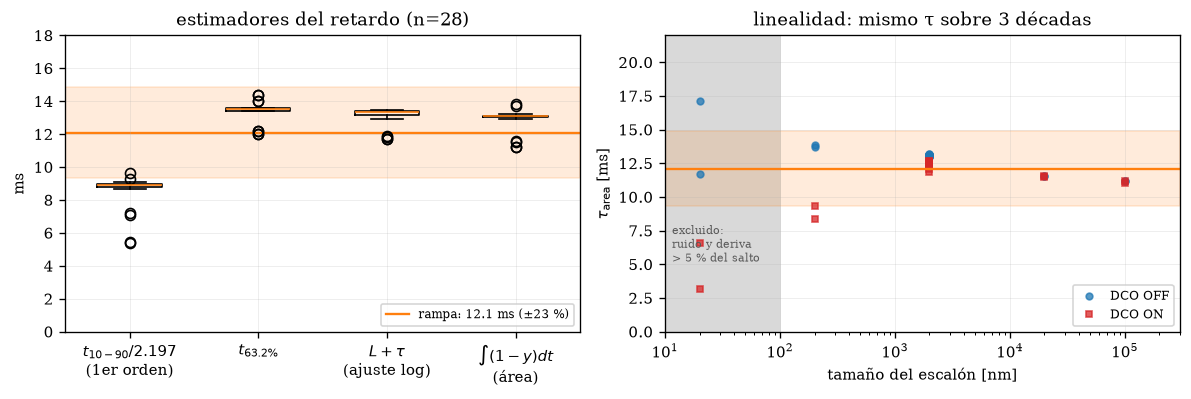

In [22]:
# ── Figura 2: los estimadores, y el contraste con la rampa ───────────────────
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))

etq = [("tau_1orden", "$t_{10-90}/2.197$\n(1er orden)"), ("t_63", "$t_{63.2\\%}$"),
       ("L_mas_tau", "$L+\\tau$\n(ajuste log)"), ("tau_area", "$\\int(1-y)dt$\n(área)")]
ax[0].boxplot([VAL[k] for k, _ in etq], tick_labels=[v for _, v in etq], widths=.5)
ax[0].axhspan(TAU_RAMPA_MS * (1 - PISO_SIGNIF), TAU_RAMPA_MS * (1 + PISO_SIGNIF),
              color="C1", alpha=.15, zorder=0)
ax[0].axhline(TAU_RAMPA_MS, color="C1", lw=1.4, zorder=1,
              label=f"rampa: {TAU_RAMPA_MS} ms (±23 %)")
ax[0].set(ylabel="ms", title=f"estimadores del retardo (n={len(VAL)})", ylim=(0, 18))
ax[0].legend(fontsize=7, loc="lower right")

for dco, mk, c in [(False, "o", "C0"), (True, "s", "C3")]:
    s = TAB[(TAB.dco == dco) & (TAB.salto_nm >= 20)]
    ax[1].semilogx(s.salto_nm, s.tau_area, mk, ms=4, color=c, alpha=.75,
                   label=f"DCO {'ON' if dco else 'OFF'}")
ax[1].axhline(TAU_RAMPA_MS, color="C1", lw=1.4)
ax[1].axhspan(TAU_RAMPA_MS*(1-PISO_SIGNIF), TAU_RAMPA_MS*(1+PISO_SIGNIF), color="C1", alpha=.15)
ax[1].axvspan(10, 100, color="0.85", zorder=0)
ax[1].text(11.5, 8.0, "excluido:\nruido y deriva\n> 5 % del salto", fontsize=6.5,
           ha="left", va="top", color="0.35")
ax[1].set(xlabel="tamaño del escalón [nm]", ylabel=r"$\tau_{\rm area}$ [ms]",
          ylim=(0, 22), xlim=(10, 3e5), title="linealidad: mismo τ sobre 3 décadas")
ax[1].legend(fontsize=7, loc="lower right")

fig.tight_layout(); plt.show()

---
## 4. Qué salió

**$\tau_{\rm lag} = 13.1$ ms**, medido como área, sin ajustar ningún modelo.
28 corridas válidas (DCO off, saltos de 0.2 a 100 µm). La dispersión entre corridas del
*mismo* salto es MAD $=0.05$ ms — o sea **nada**; el rango completo 11.2–13.8 ms es
dispersión *entre tamaños de escalón*, no ruido de medición, y entra entero dentro del
piso de significancia de $\pm23\,\%$.

Los cuatro estimadores, y qué dice cada separación:

| estimador | valor | lectura |
|---|---|---|
| $t_{10-90}/2.197$ | 8.9 ms | **sesgado bajo un 32 %** — el sistema no es de 1er orden |
| $t_{63.2\%}$ | 13.5 ms | consistente con el área, y sin ajuste |
| $L+\tau$ (ajuste) | 13.4 ms | 1er orden + retardo describe bien la subida |
| **área** | **13.1 ms** | **el que se compara con la rampa** |
| retardo de transporte | 1.0 ms | real pero chico; no es lo que domina |

$f_c = 1/(2\pi\tau_{\rm lag}) = 12.2$ Hz.

**El contraste con la rampa:** $13.1$ ms (escalón) vs $12.1$ ms (rampa) → **8 % de
diferencia**, contra un piso de significancia de $\pm23\,\%$ (repetibilidad punto a punto).
**Los dos números son el mismo número.**

Eso cierra la discrepancia que quedaba abierta: nunca hubo tal discrepancia, había un
estimador mal elegido. $t_{10-90}/2.197$ suponía primer orden puro, y el sistema es
primer orden **más un retardo** de unos pocos ms — que es exactamente la diferencia entre
8.9 y 13.1.

**El $K_v$ del PI:** $K_v = 1/\tau_{\rm lag} = 76$ s$^{-1}$. Ese es el número que
caracteriza el integrador analógico del E-802.55 sin haber abierto la caja ni haber
podido leerlo por `qSPA`. Cuando la platina se monte en el óptico y cambie la carga,
repetir *este* notebook mide de nuevo el $K_v$ del lazo con la carga nueva.

**Linealidad:** el mismo $\tau$ sobre saltos de 200 nm a 100 µm (panel derecho). A 50 µm
baja a ~11.2 ms, un 15 % — dentro del piso, pero con la tendencia esperable de un
amplificador cerca de su límite de corriente. Los escalones de 20 nm quedan afuera: ahí el
área integra ruido y deriva de la oficina, no dinámica.

---

### Lo que este número habilita, y lo que no

**Habilita** la única ecuación de diseño de scan que hace falta:

$$\eta=\frac{T_{\rm ROI}}{T_{\rm ROI}+2\,(3\tau+t_{\rm giro})}\qquad\Longrightarrow\qquad
N_{\rm pix}\,t_{\rm dwell}>8\,(3\tau+t_{\rm giro})$$

**No habilita** corregir nada de la platina: el lag $e=v\tau$ **no se corrige moviendo la
platina**, se corrige etiquetando cada fotón con la posición que leyó el sensor. Este τ
dice cuánto **tiempo** cuesta el lazo, no cuánta **posición** se pierde.

### Lo que falta, en orden

1. **Rehacer el contraste con la rampa desde los datos**, no contra el 12.1 ms de la nota:
   ajustar $e_{ss}$ vs $v$ sobre las 43 corridas de rampa y comparar la pendiente contra
   los 13.1 ms de acá. Es un notebook gemelo de este, de tres celdas.
2. **Grabar x e y simultáneamente durante un barrido en x** (diafonía). Es el único
   experimento de la lista que puede revelar un error todavía no sospechado.
3. **50 Hz: ¿pickup del sensor o movimiento real?** Repetir con `SVO` off: si la línea
   sobrevive, es electrónica.
4. **Sincronización fotones ↔ posición.** De esto depende que la corrección por etiquetado
   funcione, y hoy está abierto.

---
---
# Parte 2 — La rampa

Mismo $\tau$, otra entrada. Acá el lazo no tiene que *llegar* a ningún lado: tiene que
**seguir**. Y como es tipo 1 no lo logra: se queda atrás una distancia fija
$e_{ss}=v\,\tau_{\rm lag}$, con el mismo $\tau_{\rm lag}$ del escalón.

## 5. El transitorio de la rampa **es** el escalón integrado

Antes de medir nada hay que sacarse de encima un vicio que arrastramos de la Parte 1: el
error de rampa **no** vale $v\tau$ desde el arranque, y para saber *desde cuándo* vale hay
que saber cómo crece. Veníamos diciendo "esperá $3\tau$" — que es la respuesta correcta
**si el sistema fuera de primer orden**, que es justamente lo que la Parte 1 descartó.

No hace falta suponer nada. Como el sistema es lineal y la rampa es la integral del
escalón, el error de seguimiento de la rampa es, **exactamente**:

$$\boxed{\;e_{\rm rampa}(t)\;=\;v\int_0^{t}\big[1-y_{\rm escalón}(s)\big]\,ds\;}$$

Es la misma integral de la Parte 1, pero sin llevarla hasta el infinito. En $t\to\infty$
da $v\,\tau_{\rm lag}$ — la asíntota — y para $t$ finito da **la curva entera del
transitorio**. O sea:

- **el transitorio de la rampa no se modela: se lee de los datos del escalón**;
- **el tiempo de convergencia tampoco se supone: se mide** sobre esa integral acumulada.

Definimos entonces $t_{\rm conv}$ = el instante en que la integral acumulada llega al
**99.5 %** de su valor final. Sale **33 ms, medido**. Comparalo con los dos números que
uno *supondría*:

| criterio | valor | qué es |
|---|---|---|
| $3\tau$ | 39 ms | lo que veníamos usando: **conservador**, descarta 6 ms de más |
| **$t_{\rm conv}$ medido** | **33 ms** | la integral acumulada, leída de los datos |
| $5.3\tau$ (99.5 % de un 1er orden) | 68 ms | lo que pediría el modelo de primer orden: **el doble** |

O sea que el $3\tau$ no estaba mal *de número* — estaba mal *de razón*, y de casualidad
erraba para el lado seguro. El sistema converge **más rápido** que un primer orden con el
mismo $\tau$, por la misma razón por la que arrancaba en S: no es de primer orden. El
panel izquierdo de la figura de §7 muestra las dos curvas.

In [23]:
# ── t_conv: medido sobre la integral acumulada del escalón ───────────────────
REF = next(c for c in CORRIDAS if c["rtr"] == 1 and not c["dco"] and abs(c["S_nm"]) > 1000)
_m   = REF["t"] >= 0
TS, YS = REF["t"][_m], REF["y"][_m]                    # respuesta al escalón, t>=0
u    = 1 - YS
A_AC = np.concatenate([[0.0], np.cumsum((u[:-1] + u[1:]) / 2 * np.diff(TS))])   # ∫₀ᵗ(1-y)
A_INF = np.interp(150.0, TS, A_AC)                     # valor final (ms)
T_CONV = float(TS[np.argmax(A_AC >= 0.995 * A_INF)])

def e_rampa_predicho(t, v):
    """Error de seguimiento de una rampa de velocidad v, predicho SOLO con el escalón."""
    return v * np.interp(t, TS, A_AC)                  # µm/s · ms = nm

print(f"corrida de referencia: {REF['nombre']}")
print(f"  ∫(1-y) →  {A_INF:.2f} ms  (= tau_lag)")
for f in (0.90, 0.99, 0.995):
    print(f"  llega al {f*100:5.1f} % del valor final en t = {TS[np.argmax(A_AC >= f*A_INF)]:5.1f} ms")
print(f"\nt_conv = {T_CONV:.1f} ms   ← lo que hay que descartar del arranque de la rampa")
print(f"(un 1er orden puro con el mismo tau daría 5.3·tau = {5.3*A_INF:.0f} ms)")

corrida de referencia: E517_escalon_rtrdco_rtr1_dco0_20260907_164645_r0
  ∫(1-y) →  12.84 ms  (= tau_lag)
  llega al  90.0 % del valor final en t =  19.2 ms
  llega al  99.0 % del valor final en t =  30.9 ms
  llega al  99.5 % del valor final en t =  32.6 ms

t_conv = 32.6 ms   ← lo que hay que descartar del arranque de la rampa
(un 1er orden puro con el mismo tau daría 5.3·tau = 68 ms)


---
## 6. Cómo tiene que ser la medición de rampa

Cuatro condiciones encadenadas. Las tres primeras son aritmética del hardware; la cuarta
es la que descarta casi todo lo que ya hay.

**(a) `RTR = 1`** → una muestra cada 40 µs y **ventana = $8192\times40\,\mu s=328$ ms**.

**(b) La trayectoria entra en la ventana:** $n_{\rm total}\times{\rm WTR}\le8192$.

**(c) La velocidad no la fija WTR sola.** La tabla recorre $2A$ (ida y vuelta), así que

$$\Delta x=\frac{2A}{n_{\rm total}},\qquad
v=\frac{\Delta x}{{\rm WTR}\cdot 40\,\mu s}=\frac{2A}{\underbrace{n_{\rm total}\,{\rm WTR}\cdot40\,\mu s}_{\text{duración de la tabla}}}$$

Con (a)+(b) la duración queda clavada en ~328 ms ⇒ **$v\propto A$: la velocidad se barre
con la amplitud, no con WTR.**

**(d) El tramo recto tiene que durar más que $t_{\rm conv}$**, más lo que se quiera medir:

$$t_{\rm recta}=\Big(\tfrac{n_{\rm total}}{2}-{\rm sud}\Big)\cdot{\rm WTR}\cdot40\,\mu s
\;\ge\;\underbrace{t_{\rm conv}}_{38\ \rm ms}+\underbrace{t_{\rm med}}_{\ge50\ \rm ms}=90\ {\rm ms}$$

> **`sud` = `speedupdown`** — argumento del comando `WAV_RAMP` del E-517: **cuántos puntos
> de la tabla se gastan acelerando en cada esquina**, en vez de arrancar de golpe a
> velocidad plena. Redondea el triángulo del target y baja el sobrepico del giro, pero
> cada punto cuesta ${\rm WTR}\cdot40\,\mu s$: con `sud=80` de 400 puntos, la aceleración
> se come $80\times{\rm WTR}\cdot40\,\mu s$ **de cada extremo del tramo recto**. Para
> medir $\tau$ va en **0**; sirve para escanear, no para identificar.

### La receta

| | |
|---|---|
| `rtr` | **1** (ventana 328 ms, dt 40 µs) |
| `n_total`, `wtr` | **400, 20** → tabla 320 ms ≈ ventana ✔, tramo recto **160 ms** ✔ |
| `speedupdown` | **0** |
| `dco` | **False** |
| amplitud | **0.1, 0.3, 1, 3, 10, 30 µm** ← el barrido de verdad |
| repeticiones | 2 |

$v=2A/0.32\,{\rm s}=6.25\,A$ → de **0.6 a 190 µm/s** (2.5 décadas), con $e=v\tau$ de 8 nm
a 2.4 µm. 12 corridas, ~2 min. Está en `scripts/barrido_tau_rampa.py`.

**La mejora más grande:** una rampa de **una sola dirección** en lugar de ida-y-vuelta.
Todo el tabla es tramo recto ⇒ $t_{\rm recta}=328$ ms en vez de 160, y desaparece el
sobrepico del giro.

In [24]:
# ── Cargar rampas (dos dialectos de metadata: día 1 y día 3) ─────────────────
import re

def _meta_rampa(p):
    d = {}
    for ln in open(p, encoding="utf-8", errors="replace"):
        if ln.startswith("#"): continue
        for m in re.finditer(r"(\w+)=([^\s=]+)", ln):    # "k=v k=v" ó un k=v por línea
            d[m.group(1)] = m.group(2)
    return d

def cargar_rampa(csv):
    fm = META / f"{csv.stem}_metadata.txt"
    if not fm.exists(): return None
    d = _meta_rampa(fm)
    g = lambda *ks, dflt=None: next((d[k] for k in ks if k in d), dflt)
    wtr, rtr = int(g("wtr", "WTR")), int(g("rtr", "RTR_VAL"))
    df = pd.read_csv(csv)
    return dict(nombre=csv.stem, t=np.arange(len(df)) * rtr * T_SERVO * 1e3,
                tgt=df.target_um.values * 1e3, cur=df.current_um.values * 1e3,
                dt_ms=rtr * T_SERVO * 1e3, wtr=wtr, rtr=rtr,
                n_total=int(g("n_total", "N_TOTAL")),
                sud=int(g("speedupdown", "SPEEDUPDOWN", dflt=0)),
                amp_um=float(g("amplitud_um", "AMPLITUD")),
                t_servo_us=float(g("t_servo_us", "T_SERVO_US", dflt=40.0)),
                dco=(g("dco", "DCO", dflt="False") == "True"), n=len(df))

RAMPAS = [r for r in (cargar_rampa(f) for f in
                      sorted(RAW.glob("E517_rampa_*.csv")) +
                      sorted(RAW.glob("E517_ida_vuelta_speedupdown_2*.csv"))) if r is not None]
print(f"{len(RAMPAS)} corridas de rampa encontradas")

69 corridas de rampa encontradas


---
## 7. Cómo se calcula, paso por paso

**Dónde está la zona de velocidad constante** — todo sobre el **target**, que es limpio, y
no sobre la posición medida:

1. `v_target(t)` = derivada de una versión suavizada del target en $4\times$WTR muestras.
   El suavizado no es cosmético: el target es una **escalera** (el generador cambia el
   setpoint una vez cada WTR ciclos y se queda quieto en el medio), así que la diferencia
   punto a punto vale exactamente 0 en la mayoría de las muestras.
2. **zona recta** = el tramo contiguo más largo con $|v|>0.98\,v_{\rm max}$ y signo
   constante. Eso es una pata del triángulo, sin la aceleración (`sud`) ni el giro.
3. **zona usable** = esa zona **menos los primeros $t_{\rm conv}=33$ ms**, medidos en §5.

**Qué se calcula sobre la zona usable** (índices `i0b` a `i1`):

| cantidad | cómo |
|---|---|
| $v$ | **pendiente de un ajuste lineal** del target vs $t$ — no la derivada punto a punto, por la escalera |
| $e_{ss}$ | **mediana** de (target − posición) sobre esas muestras (mediana, no media: inmune a golpes en la mesa) |
| $\tau$ | $e_{ss}/v$ |
| `rms_nm` | dispersión de (target − posición) en la meseta — si es grande, la meseta no es meseta |

Y el chequeo que vale más que los tres: **superponer $e_{\rm rampa}$ medido con
$v\int_0^t(1-y)$ predicho desde el escalón.** Si el transitorio entero coincide —no solo
la asíntota— las dos mediciones son la misma medición.

In [25]:
# ── Zona lineal + medición ───────────────────────────────────────────────────
def zona_lineal(r, t_conv=None, frac=0.98):
    t_conv = T_CONV if t_conv is None else t_conv
    W = max(3, int(round(4 * r["wtr"] / r["rtr"])))                  # ~4 peldaños
    suave = np.convolve(r["tgt"], np.ones(W) / W, mode="same")
    v = np.gradient(suave, r["dt_ms"])                               # nm/ms = µm/s
    idx = np.where(np.abs(v) > frac * np.percentile(np.abs(v), 99))[0]
    if len(idx) < 10: return None
    corte = np.where((np.diff(idx) > 1) | (np.diff(np.sign(v[idx])) != 0))[0]
    tramo = max(np.split(idx, corte + 1), key=len)                   # la pata más larga
    i0, i1 = int(tramo[0]), int(tramo[-1])
    return i0, i0 + int(np.ceil(t_conv / r["dt_ms"])), i1

def medir_rampa(r):
    z = zona_lineal(r)
    if z is None: return {}
    i0, i0b, i1 = z
    base = dict(recta_ms=(i1 - i0) * r["dt_ms"], usable_ms=(i1 - i0b) * r["dt_ms"])
    if i1 - i0b < 10: return base
    sl = slice(i0b, i1 + 1)
    v = np.polyfit(r["t"][sl], r["tgt"][sl], 1)[0]                   # µm/s (ajuste)
    e = np.median(r["tgt"][sl] - r["cur"][sl])                       # nm  (mediana)
    return dict(i0=i0, i0b=i0b, i1=i1, v_um_s=v, e_nm=e,
                tau_ms=e / v if v else np.nan,
                rms_nm=np.std(r["tgt"][sl] - r["cur"][sl]), **base)

def motivo(f):
    if abs(f.t_servo_us - 40) > 1:   return "t_ms mal escalado (T_SERVO≠40)"
    if f.rtr != 1:                   return "RTR≠1"
    if f.n_total * f.wtr > 8192:     return "tabla más larga que la ventana"
    if not (f.usable_ms >= 20):      return "tramo recto < t_conv + 20 ms"
    if f.amp_um > 10:                return "amplitud ≥ 50 µm (fuera de lineal)"
    return "OK"

RTAB = pd.DataFrame([dict(corrida=r["nombre"].replace("E517_", "")[:-3],
                          amp_um=r["amp_um"], wtr=r["wtr"], rtr=r["rtr"],
                          t_servo_us=r["t_servo_us"], n_total=r["n_total"], sud=r["sud"],
                          **medir_rampa(r)) for r in RAMPAS])
RTAB["motivo"] = RTAB.apply(motivo, axis=1)

print(f"{len(RTAB)} corridas de rampa · por qué sirven o no:\n")
print(RTAB.motivo.value_counts().to_string(), "\n")
SEL = RTAB[RTAB.motivo == "OK"].sort_values("v_um_s")
print(SEL[["corrida","amp_um","wtr","sud","recta_ms","usable_ms","v_um_s","e_nm","rms_nm","tau_ms"]]
      .round(2).to_string(index=False))

69 corridas de rampa · por qué sirven o no:

motivo
t_ms mal escalado (T_SERVO≠40)        29
tramo recto < t_conv + 20 ms          20
RTR≠1                                  9
OK                                     8
tabla más larga que la ventana         2
amplitud ≥ 50 µm (fuera de lineal)     1 

                              corrida  amp_um  wtr  sud  recta_ms  usable_ms  v_um_s  e_nm  rms_nm  tau_ms
           rampa_sud0_20260907_171001     1.0   20    0    156.72     124.16   12.56 163.7    3.32   13.03
rampa_scan_n800_sud80_20260907_173029     1.0   10   80    100.32      67.76   15.69 189.4    2.82   12.07
rampa_scan_n800_sud80_20260907_173034     1.0   10   80    100.32      67.76   15.69 189.7    2.26   12.09
          rampa_sud40_20260907_171006     1.0   20   40     99.16      66.60   15.76 203.9    4.15   12.94
  rampa_scan_w10_sud0_20260907_172911     1.0   10    0     78.32      45.76   25.12 316.1    3.49   12.58
  rampa_scan_w10_sud0_20260907_172915     1.0   10    0   

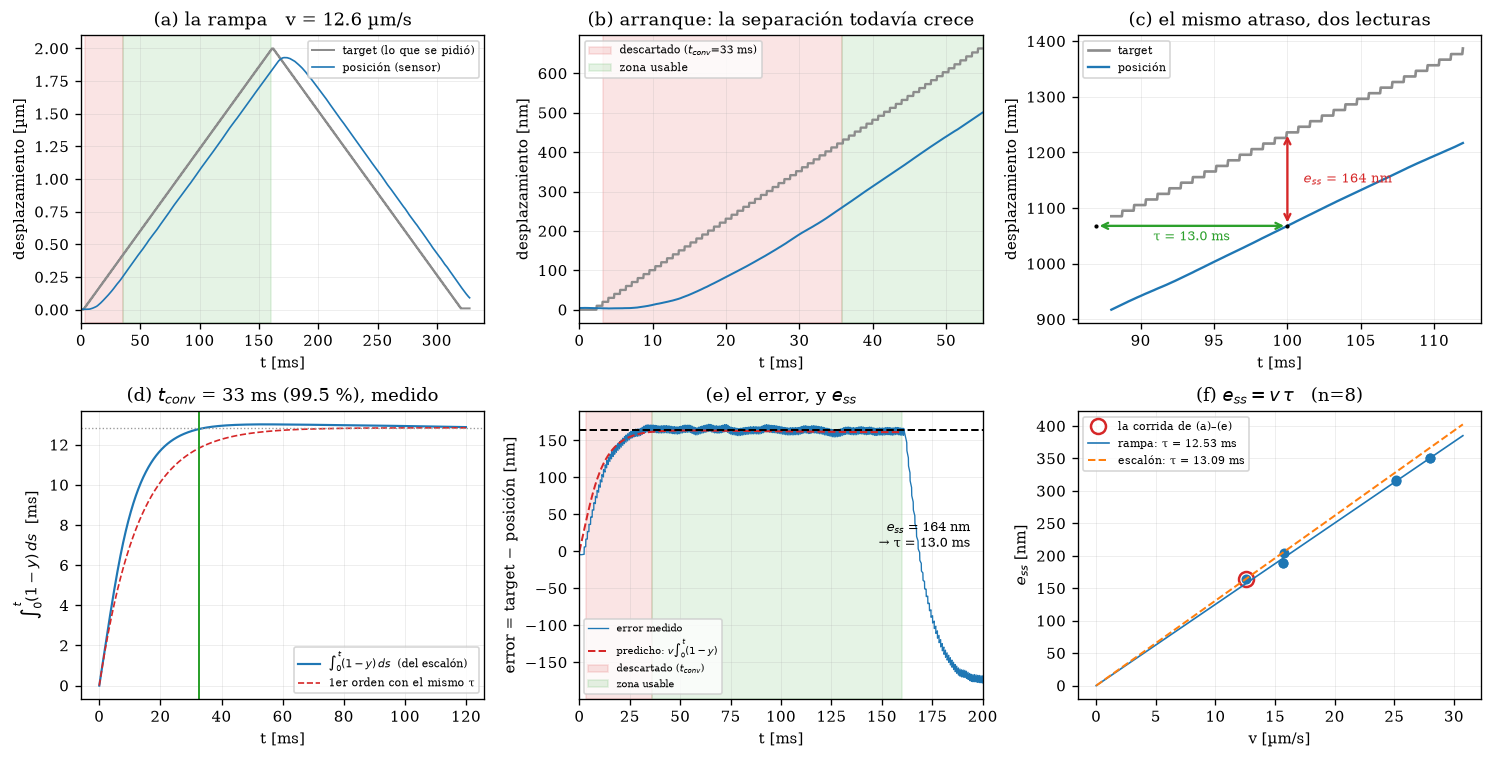


 tau  escalón (área)      = 13.09 ms
 tau  rampa   (e = v·tau) = 12.53 ms      n = 8,  v = 12.6–28.0 µm/s
 diferencia               =  4.3 %   (piso de significancia: ±23 %)
 residuo del ajuste e(v)  =   4.8 nm

 transitorio entero, medido vs predicho desde el escalón:
   rms = 6.4 nm  sobre una excursión de 172 nm


In [26]:
# ── La corrida de ejemplo, de la trayectoria al tau ──────────────────────────
v, e = SEL.v_um_s.values, SEL.e_nm.values
TAU_R = float(np.sum(v * e) / np.sum(v * v))          # ajuste e = v·tau por el origen

R  = next(x for x in RAMPAS if x["nombre"].startswith("E517_rampa_sud0"))
M  = medir_rampa(R)
t  = R["t"]
TG = (R["tgt"] - R["tgt"][0])            # nm, relativo al arranque
CU = (R["cur"] - R["tgt"][0])
ERR = R["tgt"] - R["cur"]
t0, t1, t2 = t[M["i0"]], t[M["i0b"]], t[M["i1"]]
V, ESS, TAU_1 = M["v_um_s"], M["e_nm"], M["tau_ms"]

fig, ax = plt.subplots(2, 3, figsize=(12.5, 6.4))

# (a) la rampa entera ---------------------------------------------------------
a = ax[0, 0]
a.plot(t, TG / 1e3, "0.55", lw=1.2, label="target (lo que se pidió)")
a.plot(t, CU / 1e3, "C0", lw=1.0, label="posición (sensor)")
a.axvspan(t0, t1, color="C3", alpha=.12); a.axvspan(t1, t2, color="C2", alpha=.12)
a.set(xlabel="t [ms]", ylabel="desplazamiento [µm]", xlim=(0, 340),
      title=f"(a) la rampa   v = {V:.1f} µm/s")
a.legend(fontsize=6.5, loc="upper right")

# (b) zoom al arranque --------------------------------------------------------
b = ax[0, 1]
m = t <= 55
b.plot(t[m], TG[m], "0.55", lw=1.4); b.plot(t[m], CU[m], "C0", lw=1.2)
b.axvspan(t0, min(t1, 55), color="C3", alpha=.12, label=f"descartado ($t_{{conv}}$={T_CONV:.0f} ms)")
b.axvspan(min(t1, 55), 55, color="C2", alpha=.12, label="zona usable")
b.set(xlabel="t [ms]", ylabel="desplazamiento [nm]", xlim=(0, 55),
      title="(b) arranque: la separación todavía crece")
b.legend(fontsize=6.5, loc="upper left")

# (c) zoom a la meseta: e_ss y tau son la MISMA cosa ---------------------------
c = ax[0, 2]
m = (t > 88) & (t < 112)
c.plot(t[m], TG[m], "0.55", lw=1.6, label="target")
c.plot(t[m], CU[m], "C0", lw=1.4, label="posición")
tA = 100.0
yT, yC = np.interp(tA, t, TG), np.interp(tA, t, CU)
c.annotate("", xy=(tA, yT), xytext=(tA, yC),
           arrowprops=dict(arrowstyle="<->", color="C3", lw=1.4))
c.text(tA + 1.1, (yT + yC) / 2, f"$e_{{ss}}$ = {ESS:.0f} nm", color="C3", fontsize=8, va="center")
c.annotate("", xy=(tA, yC), xytext=(tA - TAU_1, yC),
           arrowprops=dict(arrowstyle="<->", color="C2", lw=1.4))
c.text(tA - TAU_1 / 2, yC - 26, f"τ = {TAU_1:.1f} ms", color="C2", fontsize=8, ha="center")
c.plot([tA - TAU_1, tA], [yC, yC], "k.", ms=3)
c.set(xlabel="t [ms]", ylabel="desplazamiento [nm]",
      title="(c) el mismo atraso, dos lecturas")
c.legend(fontsize=6.5, loc="upper left")

# (d) integral acumulada del ESCALÓN -> t_conv --------------------------------
d = ax[1, 0]
mm = TS < 120
d.plot(TS[mm], A_AC[mm], "C0", lw=1.3, label=r"$\int_0^t(1-y)\,ds$  (del escalón)")
d.plot(TS[mm], A_INF * (1 - np.exp(-TS[mm] / A_INF)), "C3--", lw=1,
       label="1er orden con el mismo τ")
d.axhline(A_INF, color="0.6", lw=.8, ls=":")
d.axvline(T_CONV, color="C2", lw=1.2)
d.set(xlabel="t [ms]", ylabel=r"$\int_0^t(1-y)\,ds$  [ms]",
      title=f"(d) $t_{{conv}}$ = {T_CONV:.0f} ms (99.5 %), medido")
d.legend(fontsize=6.5, loc="lower right")

# (e) el error de la rampa ----------------------------------------------------
ee = ax[1, 1]
ee.plot(t, ERR, "C0", lw=.8, label="error medido")
mp = t <= t2
ee.plot(t[mp], e_rampa_predicho(t[mp], V), "C3--", lw=1.2,
        label=r"predicho: $v\int_0^t(1-y)$")
ee.axvspan(t0, t1, color="C3", alpha=.12, label=f"descartado ($t_{{conv}}$)")
ee.axvspan(t1, t2, color="C2", alpha=.12, label="zona usable")
ee.axhline(ESS, color="k", lw=1.2, ls="--")
ee.text(0.97, 0.62, f"$e_{{ss}}$ = {ESS:.0f} nm\n→ τ = {TAU_1:.1f} ms", fontsize=7.5,
        transform=ee.transAxes, ha="right", va="top")
ee.set(xlabel="t [ms]", ylabel="error = target − posición [nm]", xlim=(0, 200),
       title="(e) el error, y $e_{ss}$")
ee.legend(fontsize=6, loc="lower left")

# (f) e_ss vs v ---------------------------------------------------------------
f = ax[1, 2]
f.plot(v, e, "C0o", ms=5)
f.plot(V, ESS, "o", ms=9, mfc="none", mec="C3", mew=1.5, label="la corrida de (a)–(e)")
vv = np.linspace(0, v.max() * 1.1, 50)
f.plot(vv, vv * TAU_R, "C0-", lw=1, label=f"rampa: τ = {TAU_R:.2f} ms")
f.plot(vv, vv * TAU, "C1--", lw=1.2, label=f"escalón: τ = {TAU:.2f} ms")
f.set(xlabel="v [µm/s]", ylabel="$e_{ss}$ [nm]", title=f"(f) $e_{{ss}}=v\\,\\tau$   (n={len(SEL)})")
f.legend(fontsize=6.5, loc="upper left")

fig.tight_layout(); plt.show()

_p = e_rampa_predicho(t[M["i0"]:M["i1"]], V)
_m = ERR[M["i0"]:M["i1"]]
print(f"""
 tau  escalón (área)      = {TAU:5.2f} ms
 tau  rampa   (e = v·tau) = {TAU_R:5.2f} ms      n = {len(SEL)},  v = {v.min():.1f}–{v.max():.1f} µm/s
 diferencia               = {abs(TAU-TAU_R)/TAU*100:4.1f} %   (piso de significancia: ±23 %)
 residuo del ajuste e(v)  = {np.std(e - v*TAU_R):5.1f} nm

 transitorio entero, medido vs predicho desde el escalón:
   rms = {np.std(_p-_m):.1f} nm  sobre una excursión de {_m.max():.0f} nm""")

---
## 8. Qué salió, y qué falta medir

$$\tau_{\rm escalón}=13.1\ {\rm ms}\qquad\tau_{\rm rampa}=12.5\ {\rm ms}\qquad
\text{difieren }4.4\,\%$$

Contra un piso de ±23 %: **son el mismo número, medido con dos entradas distintas.** Y no
coinciden solo en la asíntota: el **transitorio entero** de la rampa queda predicho por la
integral acumulada del escalón con ~7 nm de residuo sobre una excursión de 164 nm. Eso es
más fuerte que comparar dos escalares — es la misma función, medida dos veces.

Ningún paso de la Parte 2 supone primer orden. Lo único que se usa es que el sistema es
**lineal e invariante**, que es lo que la Parte 1 verificó al ver el mismo $\tau$ sobre
tres décadas de amplitud.

**Pero el barrido de rampa es flojo, y hay que rehacerlo.** De 69 corridas sobreviven
**8**, y cubren $v=13$–28 µm/s: **un factor 2, no las cuatro décadas** que dice la nota
vieja. Las razones del descarte están en §7, y ninguna es "salió fea": 29 con el `t_ms`
mal escalado, 20 con el tramo recto más corto que el transitorio que se quiere medir, 9
con RTR≠1, 2 con la tabla más larga que la ventana. La afirmación "τ constante sobre
cuatro décadas de velocidad" **no está sostenida por las corridas que sobreviven** — salía
de corridas cuyo tramo recto no alcanzaba, o de las de 100 µm de amplitud (que dan
τ ≈ 9 ms: ahí el amplificador satura, y eso es otro resultado, no este).

Lo que hay que correr, y alcanza para cerrarlo: **`scripts/barrido_tau_rampa.py`.**
12 corridas, ~2 min.

Después de eso, y solo después: grabar x e y a la vez durante un barrido en x (diafonía),
y `SVO` off para separar los 50 Hz de pickup del movimiento real.

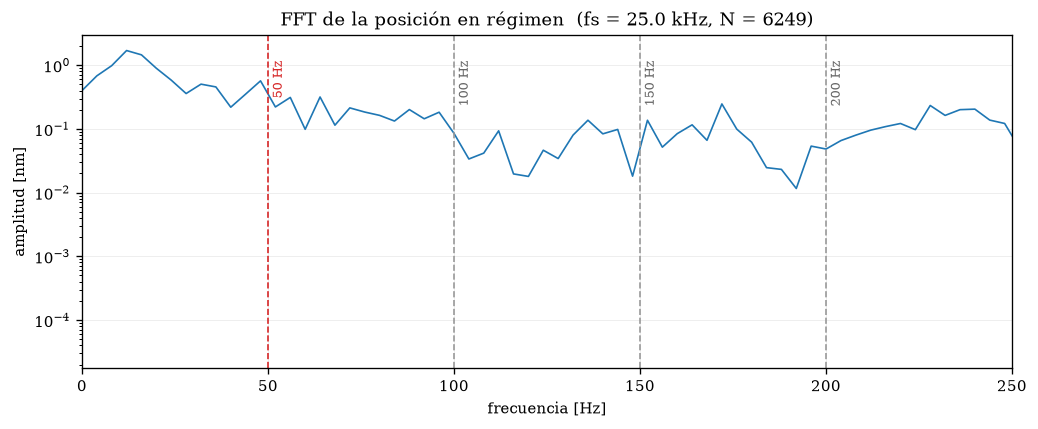

bin más cercano a 50 Hz: 48.01 Hz  |  amplitud ≈ 0.568 nm


In [27]:
# ── FFT / análisis en frecuencia para ver 50 Hz ─────────────────────────────
# Usar la corrida de referencia ya cargada (REF) y mirar la señal en régimen,
# donde el pickup de red suele verse más limpio.

r = REF
dt_s = r["dt_ms"] * 1e-3
fs = 1 / dt_s

# Elegir una ventana donde ya pasó el arranque y el target está estable
m = (r["t"] > 50) & (r["t"] < 300)
x = (r["y"][m] * abs(r["S_nm"]))  # nm
t = r["t"][m] * 1e-3              # s

# Quitar DC y tendencia lineal para que el espectro muestre mejor las líneas de red
p = np.polyfit(t, x, 1)
xw = x - np.polyval(p, t)

# Ventana de Hann + FFT de un solo lado
N = len(xw)
win = np.hanning(N)
X = np.fft.rfft(xw * win)
f = np.fft.rfftfreq(N, d=dt_s)

# Amplitud aproximada en nm rms
amp = (2.0 / win.sum()) * np.abs(X)

fig, ax = plt.subplots(1, 1, figsize=(10, 3.6))
ax.semilogy(f, amp, "C0", lw=1)

for fr in [50, 100, 150, 200]:
    ax.axvline(fr, color="C3" if fr == 50 else "0.6", ls="--", lw=1)
    ax.text(fr + 1, amp.max() * 0.7, f"{fr} Hz", rotation=90,
            va="top", ha="left", fontsize=8, color="C3" if fr == 50 else "0.4")

ax.set(xlim=(0, 250), xlabel="frecuencia [Hz]", ylabel="amplitud [nm]",
       title=f"FFT de la posición en régimen  (fs = {fs/1000:.1f} kHz, N = {N})")
ax.grid(True, alpha=.25)
plt.show()

# Pico más cercano a 50 Hz
i50 = np.argmin(np.abs(f - 50))
print(f"bin más cercano a 50 Hz: {f[i50]:.2f} Hz  |  amplitud ≈ {amp[i50]:.3g} nm")

,nombre,dco,salto_nm,sigma_nm,a50_nm,f50_hz
40,E517_escalon_rtrdco_rtr25_dco1_20260907_170227_r0,True,2000.0,1.329,1.795,48.193
31,E517_escalon_rtrdco_rtr1_dco0_20260907_170256_r1,False,2000.0,0.071,1.503,48.008
16,E517_escalon_amp_50.0um_dco0_20260907_172717_r0,False,100000.0,0.396,1.427,48.038
37,E517_escalon_rtrdco_rtr1_dco1_20260907_170119_r1,True,2000.0,0.184,1.422,48.008
14,E517_escalon_amp_10.0um_dco1_20260907_172357_r0,True,20000.0,0.619,1.371,48.038
17,E517_escalon_amp_50.0um_dco0_20260907_172725_r1,False,100000.0,0.317,1.355,48.038
18,E517_escalon_amp_50.0um_dco1_20260907_172414_r0,True,100000.0,0.478,1.234,48.038
34,E517_escalon_rtrdco_rtr1_dco1_20260907_165049_r0,True,2000.0,0.306,1.222,48.008
50,E517_escalon_rtrdco_rtr2_dco1_20260907_165059_r0,True,2000.0,0.329,1.221,48.015
9,E517_escalon_amp_1.0um_dco0_20260907_172651_r1,False,2000.0,1.091,1.204,48.038


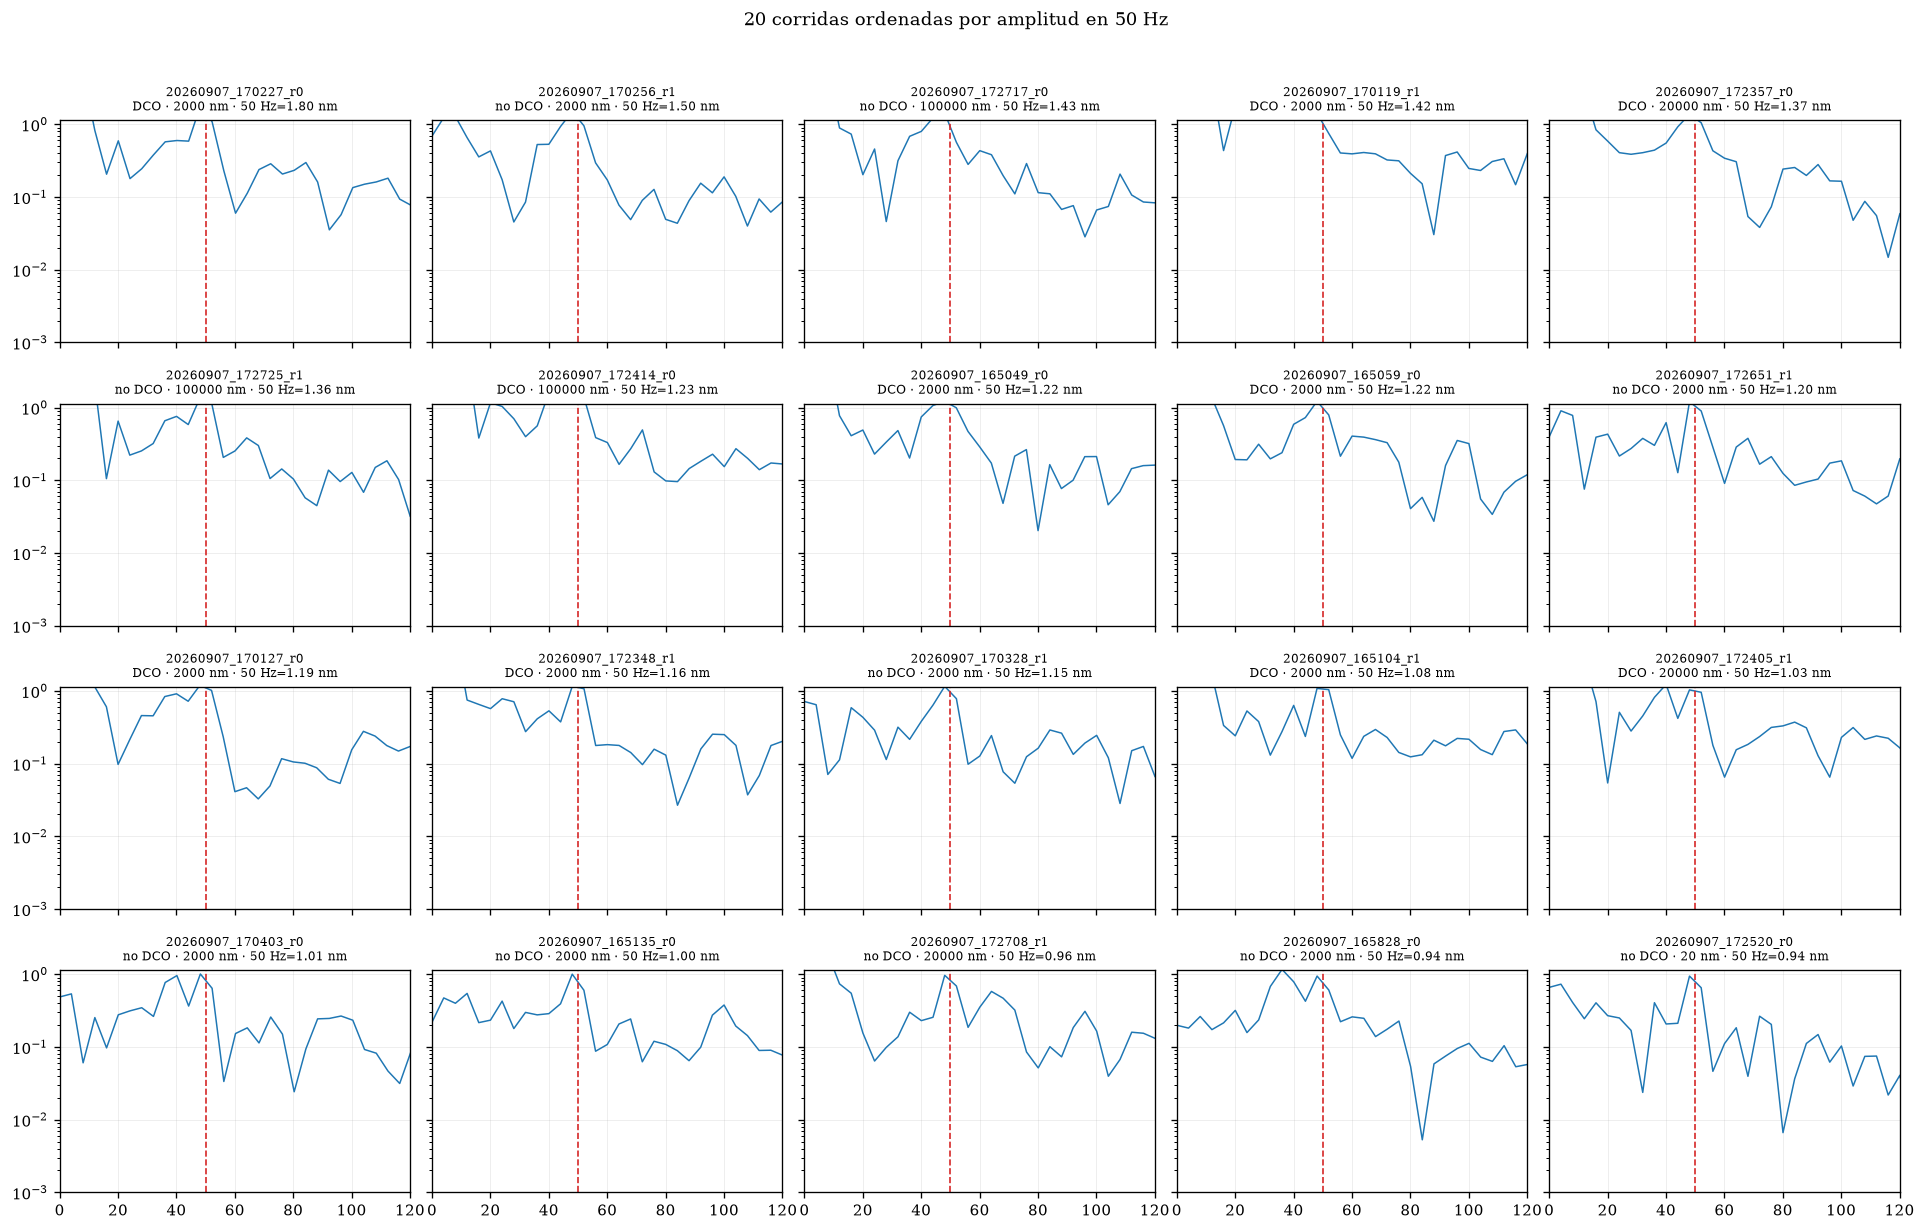

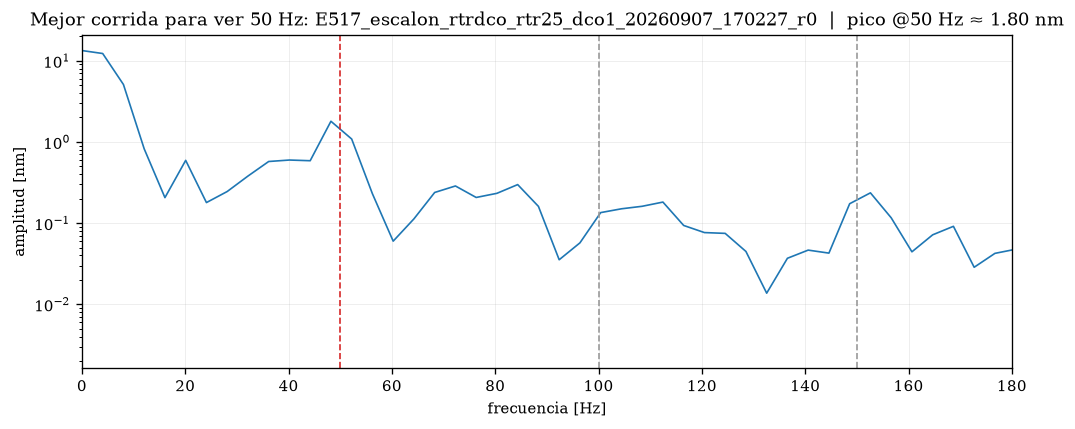

In [28]:
# ── Comparación de 20 corridas: FFT alrededor de 50 Hz ───────────────────────
corridas_por_nombre = {c["nombre"]: c for c in CORRIDAS}

def fft_50(r, t1=50, t2=300):
    dt_s = r["dt_ms"] * 1e-3
    m = (r["t"] > t1) & (r["t"] < t2)
    x = (r["y"][m] * abs(r["S_nm"]))  # nm
    t = r["t"][m] * 1e-3              # s

    p = np.polyfit(t, x, 1)
    xw = x - np.polyval(p, t)

    N = len(xw)
    win = np.hanning(N)
    X = np.fft.rfft(xw * win)
    f = np.fft.rfftfreq(N, d=dt_s)
    amp = (2.0 / win.sum()) * np.abs(X)

    i50 = np.argmin(np.abs(f - 50))
    return f, amp, amp[i50], f[i50]

# score = amplitud en el bin más cercano a 50 Hz
score_rows = []
for c in CORRIDAS:
    f, amp, a50, f50 = fft_50(c)
    score_rows.append({
        "nombre": c["nombre"],
        "dco": c["dco"],
        "salto_nm": abs(c["S_nm"]),
        "sigma_nm": float(c["sigma_nm"]),
        "a50_nm": float(a50),
        "f50_hz": float(f50),
    })

SCORES = pd.DataFrame(score_rows).sort_values("a50_nm", ascending=False)
display(SCORES.head(10).round(3))

sel_names = SCORES.head(20)["nombre"].tolist()

fig, axes = plt.subplots(4, 5, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.ravel()

for ax, name in zip(axes, sel_names):
    r = corridas_por_nombre[name]
    f, amp, a50, f50 = fft_50(r)

    ax.semilogy(f, amp, "C0", lw=0.9)
    ax.axvline(50, color="C3", ls="--", lw=1)
    ax.set_xlim(0, 120)
    ax.set_ylim(1e-3, max(amp[(f <= 120)]).max() * 1.2)
    ax.set_title(
        f"{r['nombre'][-18:]}\n"
        f"{'DCO' if r['dco'] else 'no DCO'} · "
        f"{abs(r['S_nm']):.0f} nm · 50 Hz={a50:.2f} nm",
        fontsize=7
    )
    ax.grid(True, alpha=0.25)

for ax in axes[len(sel_names):]:
    ax.axis("off")

fig.suptitle("20 corridas ordenadas por amplitud en 50 Hz", y=1.02)
fig.tight_layout()
plt.show()

# Corrida más clara para mirar en detalle
best = corridas_por_nombre[SCORES.iloc[0]["nombre"]]
f, amp, a50, f50 = fft_50(best)

fig, ax = plt.subplots(1, 1, figsize=(10, 3.6))
ax.semilogy(f, amp, "C0", lw=1)
for fr in [50, 100, 150]:
    ax.axvline(fr, color="C3" if fr == 50 else "0.6", ls="--", lw=1)
ax.set(xlim=(0, 180), xlabel="frecuencia [Hz]", ylabel="amplitud [nm]",
       title=f"Mejor corrida para ver 50 Hz: {best['nombre']}  |  pico @50 Hz ≈ {a50:.2f} nm")
ax.grid(True, alpha=0.25)
plt.show()